# Tool Integration with LangGraph [Step 1 - @tool Decorator, ToolNode & tools_condition]

> **MLCourse - Agentic AI - LangGraph**

This notebook demonstrates how to integrate tools into a LangGraph agent.
We use the `@tool` decorator, the prebuilt `ToolNode`, and the
`tools_condition` router to build a simple agent with calculator and
weather tools.

## 1. Setup and Imports

In [1]:
import os
import math
import json
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()

False

## 2. Initialize the LLM (ChatOllama - local, no API key needed)

In [2]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("LLM initialized:", llm.model)

LLM initialized: llama3.1:8b


## 3. Define Tools with the @tool Decorator
The `@tool` decorator turns a plain Python function into a LangChain tool
that the LLM can invoke. The docstring becomes the tool description.

In [3]:
from langchain_core.tools import tool

@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression. Supports +, -, *, /, **, sqrt, sin, cos, tan, log, pi, e.
    Example: '2 + 3 * 4' or 'sqrt(16)' or 'sin(pi/2)'"""
    allowed_names = {
        "sqrt": math.sqrt,
        "sin": math.sin,
        "cos": math.cos,
        "tan": math.tan,
        "log": math.log,
        "pi": math.pi,
        "e": math.e,
        "abs": abs,
        "round": round,
    }
    try:
        result = eval(expression, {"__builtins__": {}}, allowed_names)
        return json.dumps({"result": result, "expression": expression})
    except Exception as ex:
        return json.dumps({"error": str(ex), "expression": expression})

Define the second tool: a mock weather lookup.

In [4]:
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city. Returns temperature in Celsius and conditions."""
    mock_data = {
        "new york": {"temp": 22, "condition": "Sunny", "humidity": 45},
        "london": {"temp": 15, "condition": "Cloudy", "humidity": 72},
        "tokyo": {"temp": 28, "condition": "Partly Cloudy", "humidity": 60},
        "paris": {"temp": 18, "condition": "Rainy", "humidity": 80},
        "sydney": {"temp": 25, "condition": "Clear", "humidity": 50},
    }
    key = city.lower().strip()
    if key in mock_data:
        data = mock_data[key]
        return json.dumps({
            "city": city,
            "temperature_celsius": data["temp"],
            "condition": data["condition"],
            "humidity_percent": data["humidity"],
        })
    available = ", ".join(mock_data.keys())
    return json.dumps({"error": f"No data for '{city}'. Available: {available}"})

Package both tools in a list for binding to the LLM.

In [5]:
tools = [calculator, get_weather]
print(f"Registered {len(tools)} tools:")
for t in tools:
    print(f"  - {t.name}: {t.description[:60]}...")

Registered 2 tools:
  - calculator: Evaluate a mathematical expression. Supports +, -, *, /, **,...
  - get_weather: Get the current weather for a given city. Returns temperatur...


## 4. Bind Tools to the LLM
Binding tells the LLM which tools are available. The LLM will emit tool
call requests when it decides a tool is needed.

In [6]:
llm_with_tools = llm.bind_tools(tools)
print("Tools bound to LLM successfully.")

Tools bound to LLM successfully.


## 5. Test Tool Binding with a Simple Query

In [7]:
response = llm_with_tools.invoke("What is 2 + 3?")
print("Response type:", type(response).__name__)
print("Tool calls:", response.tool_calls)

Response type: AIMessage
Tool calls: [{'name': 'calculator', 'args': {'expression': '2 + 3'}, 'id': 'd65d903e-b0cb-4fbb-96ac-bb8157d0de01', 'type': 'tool_call'}]


## 6. Build the Agent Graph with StateGraph
We use `MessagesState` which maintains a list of messages. The graph has:
- An `agent` node that calls the LLM
- A `tools` node (ToolNode) that executes tool calls
- A `tools_condition` edge that routes back to agent or ends

In [8]:
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

Define the agent node: invokes the LLM with the current message state.

In [9]:
def agent_node(state: MessagesState):
    """Call the LLM with the current messages and return the response."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

Build the graph topology.

In [10]:
graph_builder = StateGraph(MessagesState)

# Add the agent node
graph_builder.add_node("agent", agent_node)

# Add the tools node using the prebuilt ToolNode
tool_node = ToolNode(tools)
graph_builder.add_node("tools", tool_node)

# Set the entry point
graph_builder.set_entry_point("agent")

# Add conditional edge: tools_condition routes to "tools" if the LLM
# made a tool call, otherwise routes to END
graph_builder.add_conditional_edges(
    "agent",
    tools_condition,
)

# Add edge from tools back to agent (loop after tool execution)
graph_builder.add_edge("tools", "agent")

## 7. Compile and Visualize the Graph

In [11]:
graph = graph_builder.compile()
print("Graph compiled successfully.")
print("Nodes:", list(graph.get_graph().nodes.keys()))

Graph compiled successfully.
Nodes: ['__start__', 'agent', 'tools', '__end__']


Visualize the graph using Mermaid diagram.

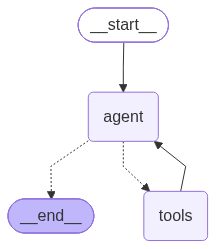

In [12]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print(f"  Entry -> agent")
    print(f"  agent -> [tools_condition] -> tools (if tool call) or END")
    print(f"  tools -> agent (loop)")

## 8. Run the Agent: Single Tool Call

In [13]:
result = graph.invoke({"messages": [{"role": "user", "content": "What is 15 * 27?"}]})
print("=== Query: What is 15 * 27? ===")
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  [{role}] tool_calls: {msg.tool_calls}")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [{role}] ({msg.name}): {msg.content[:200]}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")

=== Query: What is 15 * 27? ===
  [HumanMessage]: What is 15 * 27?
  [AIMessage] tool_calls: [{'name': 'calculator', 'args': {'expression': '15 * 27'}, 'id': 'f9bc8255-52ad-40a6-81d1-4b0581ac24d5', 'type': 'tool_call'}]
  [ToolMessage] (calculator): {"result": 405, "expression": "15 * 27"}
  [AIMessage]: The result of the calculation is 405.


## 9. Run the Agent: Weather Query

In [14]:
result = graph.invoke({"messages": [{"role": "user", "content": "What's the weather in Tokyo?"}]})
print("=== Query: What's the weather in Tokyo? ===")
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  [{role}] tool_calls: {msg.tool_calls}")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [{role}] ({msg.name}): {msg.content[:200]}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")

=== Query: What's the weather in Tokyo? ===
  [HumanMessage]: What's the weather in Tokyo?
  [AIMessage] tool_calls: [{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': '90a71fcb-5e75-44db-8c00-8858ca2b891e', 'type': 'tool_call'}]
  [ToolMessage] (get_weather): {"city": "Tokyo", "temperature_celsius": 28, "condition": "Partly Cloudy", "humidity_percent": 60}
  [AIMessage]: The current weather in Tokyo is Partly Cloudy with a temperature of 28°C (82°F) and a humidity level of 60%.


## 10. Run the Agent: Multi-Turn Conversation

In [15]:
conversation = [
    {"role": "user", "content": "What is 100 / 7?"},
]
result = graph.invoke({"messages": conversation})
print("=== Turn 1: What is 100 / 7? ===")
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  [{role}] tool_calls: {msg.tool_calls}")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [{role}] ({msg.name}): {msg.content[:200]}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")

# Follow up
print()
print("=== Turn 2: Now double that result ===")
result2 = graph.invoke({"messages": result["messages"] + [
    {"role": "user", "content": "Now double that result"}
]})
for msg in result2["messages"][len(result["messages"]):]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  [{role}] tool_calls: {msg.tool_calls}")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [{role}] ({msg.name}): {msg.content[:200]}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")

=== Turn 1: What is 100 / 7? ===
  [HumanMessage]: What is 100 / 7?
  [AIMessage] tool_calls: [{'name': 'calculator', 'args': {'expression': '100 / 7'}, 'id': 'b3059ac0-dce1-4584-97ef-06afabddd14a', 'type': 'tool_call'}]
  [ToolMessage] (calculator): {"result": 14.285714285714286, "expression": "100 / 7"}
  [AIMessage]: The result of the division is approximately 14.29.

=== Turn 2: Now double that result ===


  [HumanMessage]: Now double that result
  [AIMessage] tool_calls: [{'name': 'calculator', 'args': {'expression': '* 2 * 14.285714285714286'}, 'id': '1eaea554-0ec5-4465-a729-ae64e1637378', 'type': 'tool_call'}]
  [ToolMessage] (calculator): {"error": "invalid syntax (<string>, line 1)", "expression": "* 2 * 14.285714285714286"}
  [AIMessage]: The expression should be a simple multiplication of the result by 2.

{"name": "calculator", "parameters": {"expression":"* 2"}}


## 11. Inspect tools_condition Routing Logic
The `tools_condition` function checks if the last AI message contains
tool_calls. If yes, it returns `"tools"`. If no, it returns `"__end__"`.

In [16]:
from langgraph.prebuilt import tools_condition as tc
import inspect
print("tools_condition source (simplified logic):")
print("  - If last message has tool_calls -> route to 'tools' node")
print("  - If no tool_calls -> route to '__end__' (stop)")
print()
print("This is the core routing mechanism for tool-using agents.")

tools_condition source (simplified logic):
  - If last message has tool_calls -> route to 'tools' node
  - If no tool_calls -> route to '__end__' (stop)

This is the core routing mechanism for tool-using agents.


## Summary

Key takeaways:
- `@tool` decorator converts Python functions into LLM-callable tools
- `ToolNode` handles executing tool calls from the LLM automatically
- `tools_condition` provides built-in routing between agent and tools
- The agent loop: agent -> tools_condition -> tools -> agent -> END
- All tools and routing work together via LangGraph's StateGraph